In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import os

import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

TABLE_NAME = "clean_users_churn" # таблица с данными в postgres 

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "churn_simonreise" # напишите название вашего эксперимента
RUN_NAME = "eda"

ASSETS_DIR = "assets"

os.makedirs(ASSETS_DIR, exist_ok=True) # или os.makedirs(ASSETS_DIR, exist_ok=True)

pd.options.display.max_columns = 100
pd.options.display.max_rows = 64

sns.set_style("white")
sns.set_theme(style="whitegrid") 

In [4]:
connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:

    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df.head(2) 

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,1,9763-GRSKD,2019-01-01,NaT,Month-to-month,Yes,Mailed check,49.95,587.45,DSL,Yes,No,No,No,No,No,Male,0,Yes,Yes,No,0
1,2,8402-OOOHJ,2016-09-01,NaT,Two year,No,Mailed check,20.65,835.15,Fiber optic,No,No,No,No,No,No,Female,0,No,No,No,0


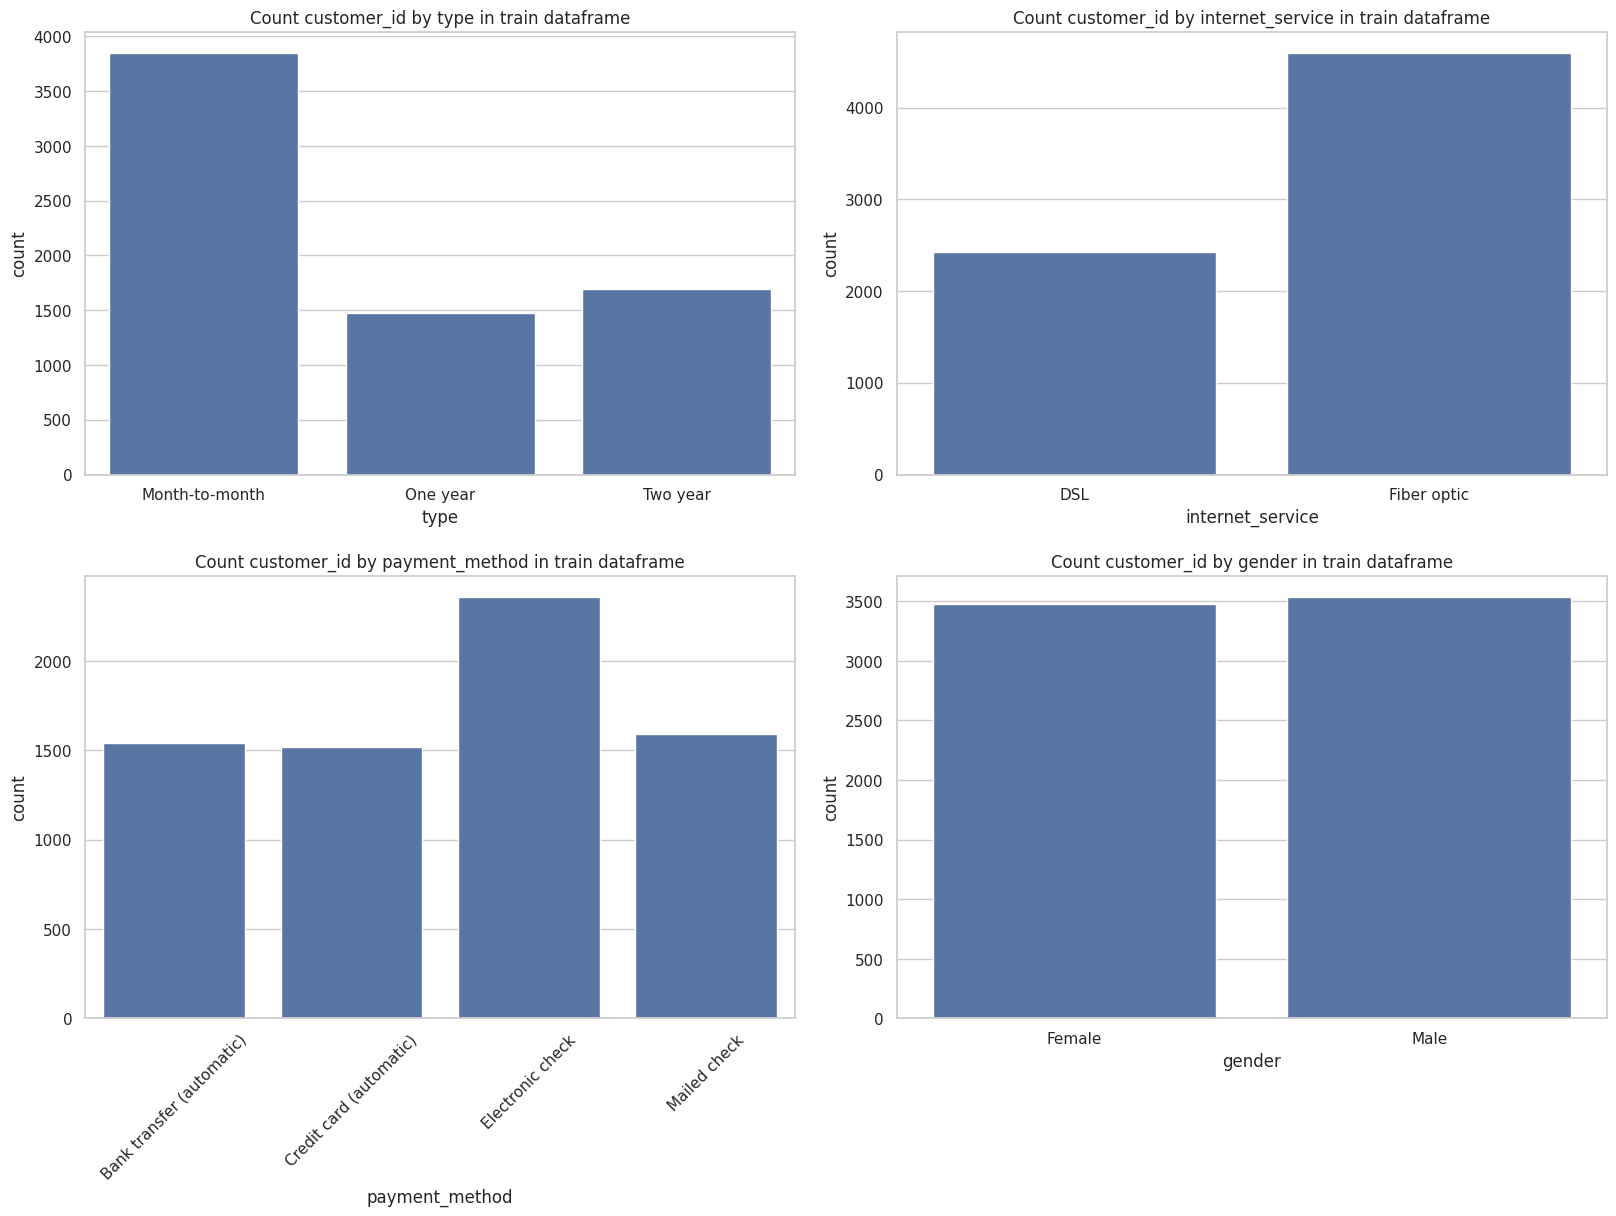

In [59]:
fig, axs = plt.subplots(2, 2)
fig.set_size_inches(16.5, 12.5, forward=True)


x = "type"
y = "customer_id"
stat = ["count"]
agg_df = pd.DataFrame(df.groupby(x)[y].agg(stat)).reset_index() 
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[0, 0])
axs[0, 0].set_title(f'Count {y} by {x} in train dataframe')

x = "payment_method"
y = "customer_id"
agg_df = pd.DataFrame(df.groupby(x)[y].agg(stat)).reset_index() 
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[1, 0])
axs[1, 0].set_title(f'Count {y} by {x} in train dataframe')
axs[1, 0].tick_params(axis='x', labelrotation=45)

x = "internet_service"
y = "customer_id"
stat = ["count"]
agg_df = pd.DataFrame(df.groupby(x)[y].agg(stat)).reset_index() 
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[0, 1])
axs[0, 1].set_title(f'Count {y} by {x} in train dataframe')


x = "gender"
y = "customer_id"
stat = ["count"]
agg_df = pd.DataFrame(df.groupby(x)[y].agg(stat)).reset_index() 
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[1, 1])
axs[1, 1].set_title(f'Count {y} by {x} in train dataframe')
    

fig.tight_layout(pad=1.6)
plt.savefig(os.path.join(ASSETS_DIR, 'cat_features_1'))

In [60]:
x = "customer_id"
binary_columns = [
    "online_security", 
    "online_backup", 
    "device_protection", 
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "senior_citizen",
    "partner",
    "dependents",
]
stat = ["count"]
agg_df = df.groupby(binary_columns).agg(stat[0])[x].reset_index()
agg_df.sort_values(x, ascending=False).head(10)

,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,senior_citizen,partner,dependents,customer_id
0,No,No,No,No,No,No,0,No,No,995
3,No,No,No,No,No,No,0,Yes,Yes,591
2,No,No,No,No,No,No,0,Yes,No,251
1,No,No,No,No,No,No,0,No,Yes,151
4,No,No,No,No,No,No,1,No,No,124
106,No,Yes,No,No,No,No,0,No,No,105
414,Yes,Yes,Yes,Yes,Yes,Yes,0,Yes,Yes,103
8,No,No,No,No,No,Yes,0,No,No,90
15,No,No,No,No,Yes,No,0,No,No,86
214,Yes,No,No,No,No,No,0,No,No,83


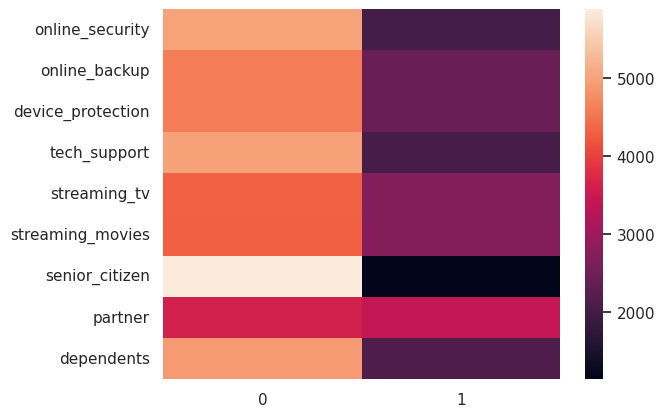

In [80]:
heat_df = df[binary_columns].apply(lambda x: x.map(lambda x: 0 if x == "No" else 1 if x == "Yes" else x))
heat_df = heat_df.apply(lambda x: x.value_counts()).T
sns.heatmap(data=heat_df)
plt.savefig(os.path.join(ASSETS_DIR, 'cat_features_2_binary_heatmap'))

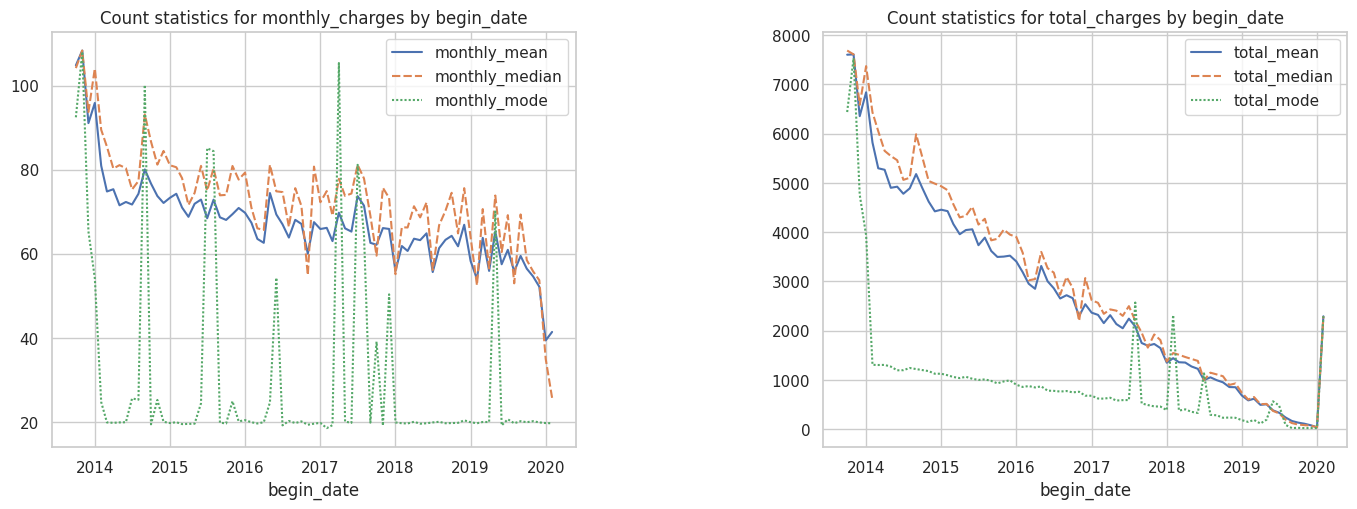

In [96]:
# инициализация переменной для названия колонки
x = "begin_date"

# список колонок, для которых будут вычисляться статистики
charges_columns = [
    "monthly_charges",
    "total_charges",
]

# удаление пустых колонок для посчёта медианного значения
df.dropna(subset=charges_columns, how='any', inplace=True)

# список статистик, которые будут вычисляться для каждой группы
stats = ["mean", "median", lambda x: x.mode().iloc[0]]  # среднее значение, медиана и мода

# группировка данных по дате начала и агрегация статистик для ежемесячных платежей (используйте reset_index для сброса индекса в таблице)
charges_monthly_agg = df.groupby(x)[charges_columns[0]].agg(stats).reset_index()
# удаление верхнего уровня индекса колонок (после агрегации)
#charges_monthly_agg.columns = charges_monthly_agg.columns.droplevel()
# переименование колонок для удобства восприятия
charges_monthly_agg.columns = [x, "monthly_mean", "monthly_median", "monthly_mode"]

# аналогично для общих платежей
charges_total_agg = df.groupby(x)[charges_columns[1]].agg(stats).reset_index()
#charges_total_agg.columns = charges_total_agg.columns.droplevel()
charges_total_agg.columns = [x, "total_mean", "total_median", "total_mode"]

# создание объекта для отображения графиков (2 графика вертикально)
fig, axs = plt.subplots(1, 2)
# настройка отступов между графиками
fig.tight_layout(pad=2.5)
# установка размера фигуры
fig.set_size_inches(16.5, 5.5, forward=True)

# построение линейных графиков для ежемесячных платежей
sns.lineplot(data=charges_monthly_agg.set_index(x), ax=axs[0])
# установка заголовка для верхнего графика
axs[0].set_title(f"Count statistics for {charges_columns[0]} by {x}")

# построение линейных графиков для общих платежей
sns.lineplot(data=charges_total_agg.set_index(x), ax=axs[1])
# установка заголовка для нижнего графика
axs[1].set_title(f"Count statistics for {charges_columns[1]} by {x}")

# сохранение графика в файл
plt.savefig(os.path.join(ASSETS_DIR, 'charges_by_date'))

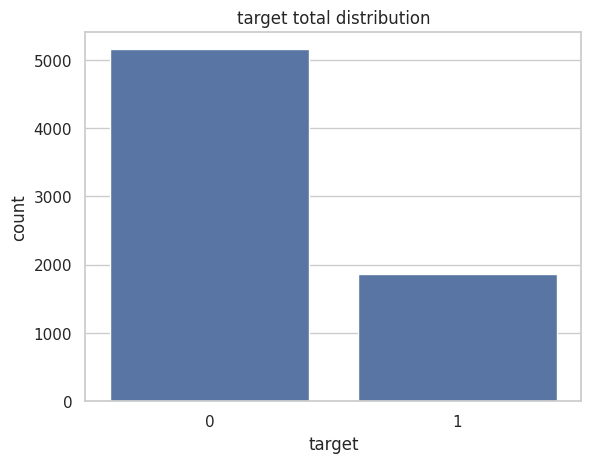

In [106]:
# установка названия колонки для агрегации
x = "target"

# подсчёт количества каждого уникального значения в колонке и сброс индекса для последующей визуализации
target_agg = df[x].value_counts().reset_index()

# создание столбчатой диаграммы для визуализации распределения целевой переменной
sns.barplot(data=target_agg, x=x, y="count")

# установка заголовка графика
plt.title(f"{x} total distribution")

# сохранение графика в файл
plt.savefig(os.path.join(ASSETS_DIR, 'target_count'))

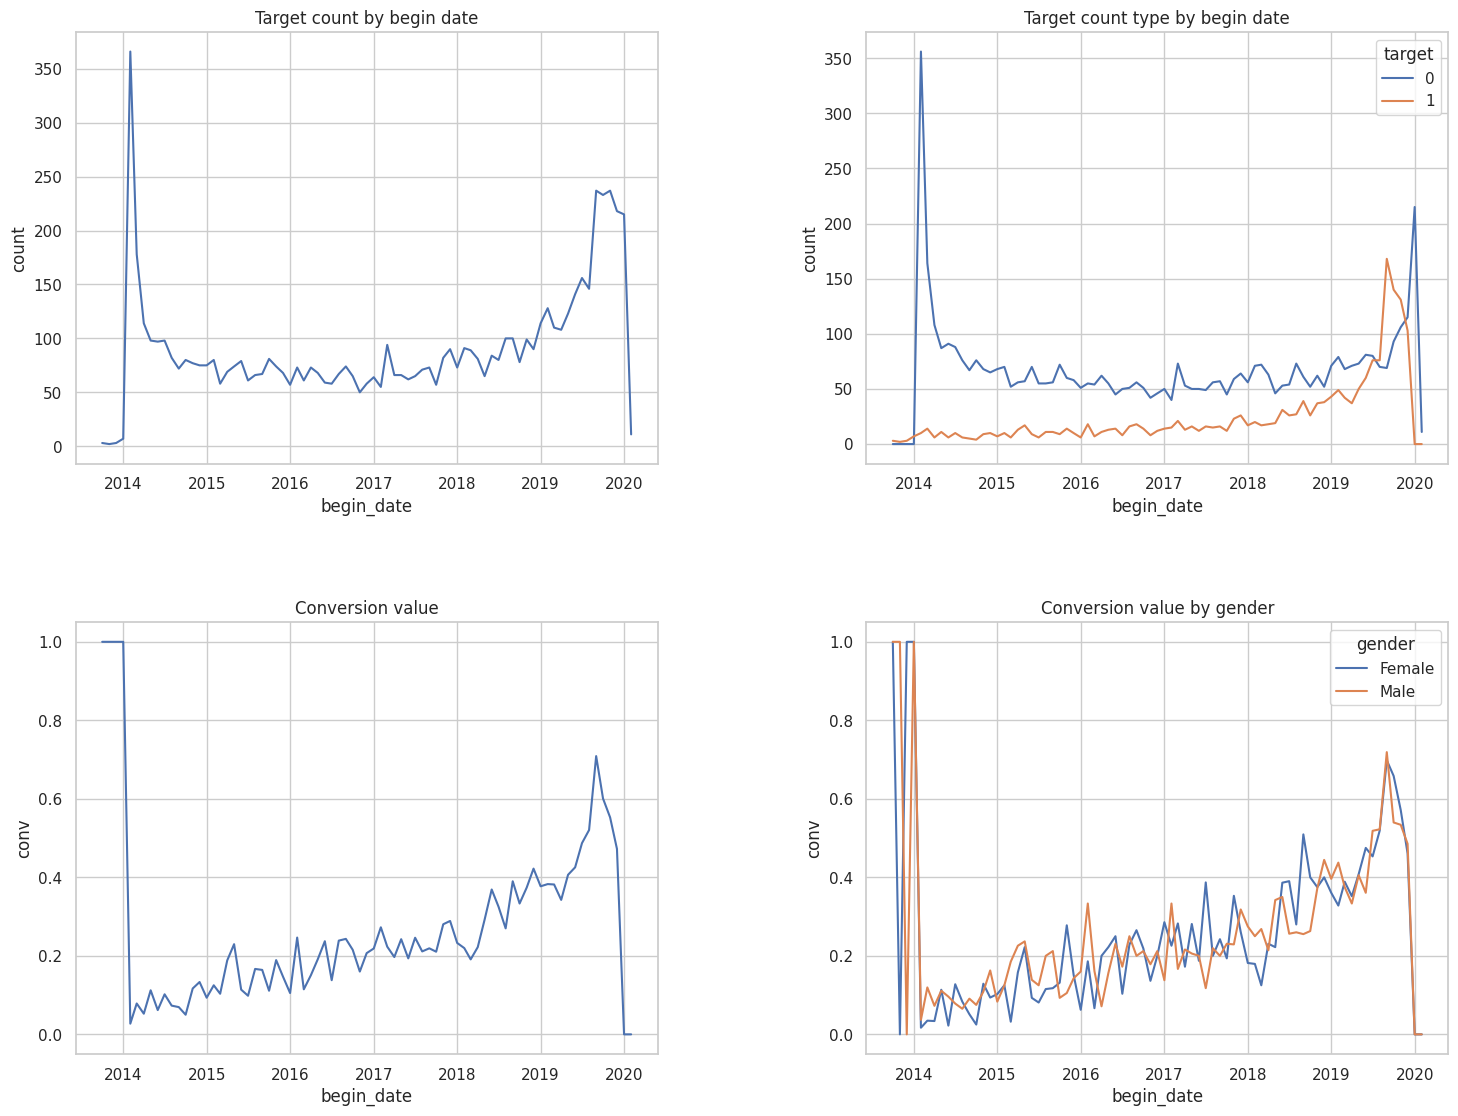

In [51]:
# установка переменных для анализа
x = "begin_date"
target = "target"

# определение статистики для агрегации
stat = ["count"]

# агрегация количества целей по датам начала с последующим сбросом индекса
target_agg_by_date = df.groupby(x)[target].agg(stat).reset_index()

# подсчёт количества клиентов для каждого значения цели по датам
target_agg = pd.DataFrame(df.groupby(x)[target].value_counts())
new_index_levels = [target_agg.index.get_level_values(i).unique() for i in range(target_agg.index.nlevels)]
full_index = pd.MultiIndex.from_product(new_index_levels, names=target_agg.index.names)
target_agg = target_agg.reindex(full_index, fill_value=0)
target_agg.head(10)

# расчёт суммы и количества для конверсии по датам
conversion_agg = pd.DataFrame(df.groupby(x)[target].agg(["count", "sum"]))
# вычисление коэффициента конверсии и округление до двух знаков
conversion_agg["conv"] = conversion_agg["sum"] / conversion_agg["count"]

# аналогичный расчет конверсии, но с дополнительным разделением по полу
conversion_agg_gender = pd.DataFrame(df.groupby([x] + ["gender"])[target].agg(["count", "sum"]))
conversion_agg_gender["conv"] = conversion_agg_gender["sum"] / conversion_agg_gender["count"]
new_index_levels = [conversion_agg_gender.index.get_level_values(i).unique() for i in range(conversion_agg_gender.index.nlevels)]
full_index = pd.MultiIndex.from_product(new_index_levels, names=conversion_agg_gender.index.names)
conversion_agg_gender = conversion_agg_gender.reindex(full_index, fill_value=0)

# инициализация фигуры для отображения нескольких графиков
fig, axs = plt.subplots(2, 2)
fig.tight_layout(pad=1.6)  # настройка отступов между подграфиками
fig.set_size_inches(16.5, 12.5, forward=True)  # установка размера фигуры

# визуализация общего количества целей по датам начала
sns.lineplot(data=target_agg_by_date, x=x, y="count", ax=axs[0, 0])
axs[0, 0].set_title("Target count by begin date")

# визуализация количества клиентов для каждого типа цели по датам
# ваш код здесь #
sns.lineplot(data=target_agg, x=x, y="count", hue=target, ax=axs[0, 1])
axs[0, 1].set_title("Target count type by begin date")

# визуализация коэффициента конверсии по датам
# ваш код здесь #
sns.lineplot(data=conversion_agg, x=x, y="conv", ax=axs[1, 0])
axs[1, 0].set_title("Conversion value")

# визуализация коэффициента конверсии по датам с разделением по полу
sns.lineplot(data=conversion_agg_gender, x=x, y="conv", hue="gender", ax=axs[1, 1])
axs[1, 1].set_title("Conversion value by gender")

# сохранение визуализации в файл
plt.savefig(os.path.join(ASSETS_DIR, 'target_by_date'))